In [1]:
%matplotlib inline

In [2]:
#format the book
import book_format
book_format.set_style()

## Introduction
## 引言

The performance of the Kalman filter is not optimal when you consider future data. For example, suppose we are tracking an aircraft, and the latest measurement deviates far from the current track, like so (I'll only consider 1 dimension for simplicity):

如果考虑未来的数据，卡尔曼滤波器的表现就不是最优的。举个例子，假设我们正在跟踪一架飞机，而最新的测量值远远偏离当前轨迹，就像这样（为简单起见，只考虑 1 维）：


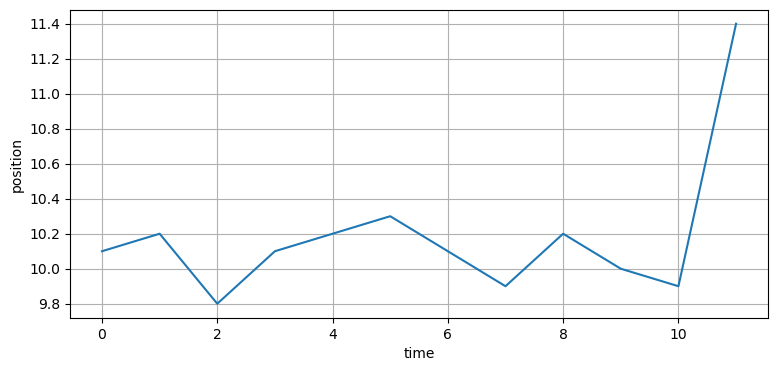

In [3]:
import matplotlib.pyplot as plt

data = [10.1, 10.2, 9.8, 10.1, 10.2, 10.3, 
        10.1, 9.9, 10.2, 10.0, 9.9, 11.4]
plt.plot(data)
plt.xlabel('time')
plt.ylabel('position');

After a period of near steady state, we have a very large change. Assume the change is past the limit of the aircraft's flight envelope. Nonetheless the Kalman filter incorporates that new measurement into the filter based on the current Kalman gain. It cannot reject the noise because the measurement could reflect the initiation of a turn. Granted it is unlikely that we are turning so abruptly, but it is impossible to say whether

在接近稳态运行一段时间之后，出现了一个非常大的变化。假设这个变化已经超出了飞机飞行包线的极限。尽管如此，卡尔曼滤波器仍会依据当前的卡尔曼增益把这个新测量并入滤波结果。它无法拒绝这一点，因为这个测量也可能意味着转弯已经开始。诚然，飞机不太可能转得如此突然，但无法断定究竟是：

* The aircraft started a turn awhile ago, but the previous measurements were noisy and didn't show the change
* 飞机前一段时间就开始转弯了，只是之前的测量噪声太大，看不出这个变化。

* The aircraft is turning, and this measurement is very noisy
* 飞机确实在转弯，只是这个测量的噪声很大

* The measurement is very noisy and the aircraft has not turned
* 测量噪声很大，飞机其实还没有转弯

* The aircraft is turning in the opposite direction, and the measurement is extremely noisy
* 飞机正在朝反方向转弯，而测量噪声极大

Now, suppose the following measurements are:

现在，假设接下来的测量值是：

    11.3 12.1 13.3 13.9 14.5 15.2


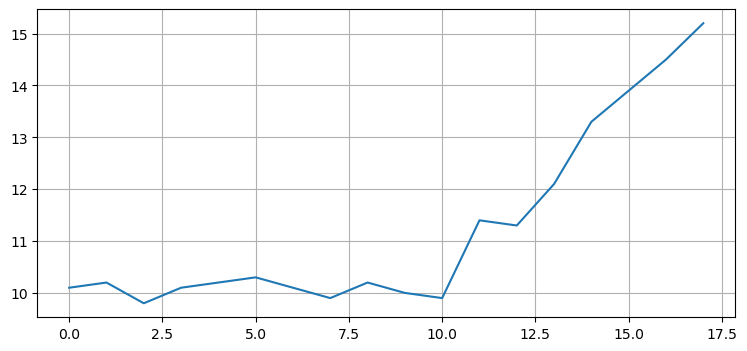

In [4]:
data2 = [11.3, 12.1, 13.3, 13.9, 14.5, 15.2]
plt.plot(data + data2);

Given these future measurements we can infer that yes, the aircraft initiated a turn.

有了这些未来的测量，我们就可以断定：是的，飞机开始转弯了。

On the other hand, suppose these are the following measurements.

反过来，假设测量值变成下面这样。


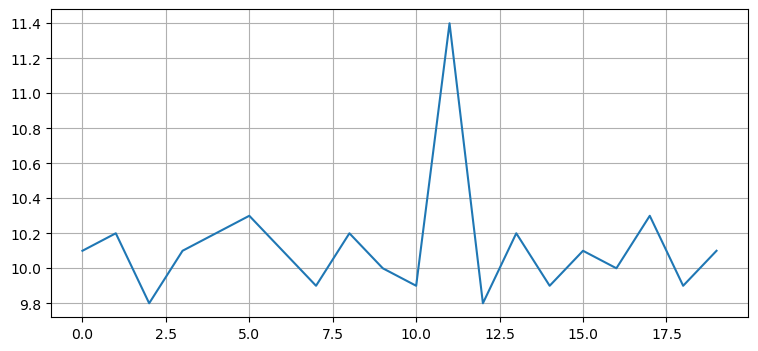

In [5]:
data3 = [9.8, 10.2, 9.9, 10.1, 10.0, 10.3, 9.9, 10.1]
plt.plot(data + data3);

In this case we are led to conclude that the aircraft did not turn and that the outlying measurement was merely very noisy.

这种情况下我们就会得出结论：飞机并没有转弯，那个离群的测量只是噪声太大而已。


## An Overview of How Smoothers Work
## 平滑器工作原理概述

The Kalman filter is a *recursive* filter with the Markov property, it's estimate at step `k` is based only on the estimate from step `k-1` and the measurement at step `k`. But this means that the estimate from step `k-1` is based on step `k-2`, and so on back to the first epoch. Hence, the estimate at step `k` depends on all of the previous measurements, though to varying degrees. `k-1` has the most influence, `k-2` has the next most, and so on.

卡尔曼滤波器是具有马尔可夫性质的*递归*滤波器，它在步骤 `k` 的估计只取决于步骤 `k-1` 的估计和步骤 `k` 的测量。但这意味着步骤 `k-1` 的估计又取决于步骤 `k-2`，如此一路追溯到最初那一步。因此，步骤 `k` 的估计其实取决于此前所有测量，只是影响程度不同：`k-1` 影响最大，`k-2` 次之，依此类推。

Smoothing filters incorporate future measurements into the estimate for step `k`. The measurement from `k+1` will have the most effect, `k+2` will have less effect, `k+3` less yet, and so on.

平滑滤波器则把未来的测量也纳入对步骤 `k` 的估计。`k+1` 的测量影响最大，`k+2` 次之，`k+3` 更小，依此类推。

This topic is called *smoothing*, but I think that is a misleading name. I could smooth the data above by passing it through a low pass filter. The result would be smooth, but not necessarily accurate because a low pass filter will remove real variations just as much as it removes noise. In contrast, Kalman smoothers are *optimal*, they incorporate all available information to make the best estimate that is mathematically achievable.

这个话题叫作*smoothing*（平滑），但我认为这个名字有误导性。我完全可以让上面的数据通过一个低通滤波器来把它变平滑，结果确实平滑，却未必准确，因为低通滤波器在滤掉噪声的同时，也会把真实的变化一并抹去。相比之下，卡尔曼平滑器是*最优的*：它综合所有可用信息，给出在数学上能够达到的最佳估计。


## Types of Smoothers
## 平滑器的类型

There are three classes of Kalman smoothers that produce better tracking in these situations.

有三类卡尔曼平滑器，能在这类情形下给出更好的跟踪结果。

* Fixed-Interval Smoothing
* 固定间隔平滑

This is a batch processing based filter. This filter waits for all of the data to be collected before making any estimates. For example, you may be a scientist collecting data for an experiment, and don't need to know the result until the experiment is complete. A fixed-interval smoother will collect all the data, then estimate the state at each measurement using all available previous and future measurements. If it is possible for you to run your Kalman filter in batch mode it is always recommended to use one of these filters as it will provide much better results than the recursive forms of the filter from the previous chapters.

这是一种基于批处理的滤波器，要等数据全部收集完毕才开始估计。例如，你可能是一位为实验采集数据的科研人员，在实验结束前并不需要知道结果。固定区间平滑器会先收齐所有数据，再利用全部已有的过去与未来测量来估计每一步的状态。如果你能把卡尔曼滤波器以批处理方式运行，就始终建议选用这一类滤波器，因为它的结果比前几章那种递归形式要好得多。

* Fixed-Lag Smoothing
* 固定滞后平滑

Fixed-lag smoothers introduce latency into the output. Suppose we choose a lag of 4 steps. The filter will ingest the first 3 measurements but not output a filtered result. Then, when the 4th measurement comes in the filter will produce the output for measurement 1, taking measurements 1 through 4 into account. When the 5th measurement comes in, the filter will produce the result for measurement 2, taking measurements 2 through 5 into account. This is useful when you need recent data but can afford a bit of lag. For example, perhaps you are using machine vision to monitor a manufacturing process. If you can afford a few seconds delay in the estimate a fixed-lag smoother will allow you to produce very accurate and smooth results.

固定滞后平滑器会在输出中引入滞后。假设我们取 4 步的滞后：滤波器先读入前 3 个测量值，但暂不输出结果；等第 4 个测量进来时，它才输出测量 1 的结果，并综合测量 1 到 4；第 5 个测量进来时，又输出测量 2 的结果，综合测量 2 到 5，依此类推。当你需要较新的数据、又能容忍一点滞后时，这就很有用。例如，你可能正用机器视觉监控某道制造工序，只要能容忍几秒钟的估计延迟，固定滞后平滑器就能给出非常准确、非常平滑的结果。

* Fixed-Point Smoothing
* 定点平滑

A fixed-point filter operates as a normal Kalman filter, but also produces an estimate for the state at some fixed time $j$. Before the time $k$ reaches $j$ the filter operates as a normal filter. Once $k>j$ the filter estimates $x_k$ and then also updates its estimate for $x_j$ using all of the measurements between $j\dots k$. This can be useful to estimate initial paramters for a system, or for producing the best estimate for an event that happened at a specific time. For example, you may have a robot that took a photograph at time $j$. You can use a fixed-point smoother to get the best possible pose information for the camera at time $j$ as the robot continues moving.

固定点平滑器平时就像普通卡尔曼滤波器一样运行，同时还会给出某个固定时刻 $j$ 的状态估计。在时刻 $k$ 尚未到达 $j$ 之前，它按普通滤波器运行；一旦 $k>j$，它除了估计 $x_k$，还会用 $j\dots k$ 之间的所有测量来更新对 $x_j$ 的估计。这对于估计系统的初始参数，或为某一特定时刻发生的事件给出最佳估计，都很有用。例如，机器人可能在时刻 $j$ 拍了一张照片；随着机器人继续运动，你可以用固定点平滑器得到相机在时刻 $j$ 的最佳位姿信息。

## Choice of Filters
## 滤波器的选择

The choice of these filters depends on your needs and how much memory and processing time you can spare. Fixed-point smoothing requires storage of all measurements, and is very costly to compute because the output is for every time step is recomputed for every measurement. On the other hand, the filter does produce a decent output for the current measurement, so this filter can be used for real time applications.

选哪一种滤波器，取决于你的需求，以及你能腾出多少内存和处理时间。固定点平滑需要存储所有测量值，而且计算开销极大，因为每来一次测量，都要重新计算每个时间步的输出。好在这种滤波器对当前测量能给出不错的输出，因此可以用在实时场合。

Fixed-lag smoothing only requires you to store a window of data, and processing requirements are modest because only that window is processed for each new measurement. The drawback is that the filter's output always lags the input, and the smoothing is not as pronounced as is possible with fixed-interval smoothing.

固定滞后平滑只需存储一个数据窗口，处理量也不算大，因为每来一个新测量只处理这个窗口。缺点是其输出总是滞后于输入，平滑程度也不如固定区间平滑那么明显。

Fixed-interval smoothing produces the most smoothed output at the cost of having to be batch processed. Most algorithms use some sort of forwards/backwards algorithm that is only twice as slow as a recursive Kalman filter.

固定区间平滑能给出最平滑的输出，代价是必须做批处理。大多数算法采用某种前向／后向算法，耗时大约只是递归卡尔曼滤波器的两倍。


## Fixed-Interval Smoothing
## 固定区间平滑

There are many fixed-lag smoothers available in the literature. I have chosen to implement the smoother invented by Rauch, Tung, and Striebel because of its ease of implementation and efficiency of computation. It is also the smoother I have seen used most often in real applications. This smoother is commonly known as an RTS smoother.

文献中的固定区间平滑器有很多。我选择实现 Rauch、Tung 和 Striebel 提出的那一种，因为它实现起来简单、计算效率又高。它也是我在实际应用里见得最多的平滑器，通常称为 RTS 平滑器。

Derivation of the RTS smoother runs to several pages of densely packed math. I'm not going to inflict it on you. Instead I will briefly present the algorithm, equations, and then move directly to implementation and demonstration of the smoother.

RTS 平滑器的推导长达好几页密集的数学。我不想把它砸给你，所以这里只简要介绍算法和方程，然后直接进入实现与演示。

The RTS smoother works by first running the Kalman filter in a batch mode, computing the filter output for each step. Given the filter output for each measurement along with the covariance matrix corresponding to each output the RTS runs over the data backwards, incorporating its knowledge of the future into the past measurements. When it reaches the first measurement it is done, and the filtered output incorporates all of the information in a maximally optimal form.

RTS 平滑器的做法是：先用批处理模式运行卡尔曼滤波器，算出每一步的滤波输出；有了每个测量的滤波输出及其对应的协方差矩阵之后，RTS 再沿数据反向运行，把对未来的了解融入过去的测量。当它倒推回第一个测量时便结束，此时滤波输出已经把所有信息以最优方式融合在一起。

The equations for the RTS smoother are very straightforward and easy to implement. This derivation is for the linear Kalman filter. Similar derivations exist for the EKF and UKF. These steps are performed on the output of the batch processing, going backwards from the most recent in time back to the first estimate. Each iteration incorporates the knowledge of the future into the state estimate. Since the state estimate already incorporates all of the past measurements the result will be that each estimate will contain knowledge of all measurements in the past and future. Here is it very important to distinguish between past, present, and future so I have used subscripts to denote whether the data is from the future or not.

RTS 平滑器的方程很直白，也容易实现。这里的推导针对线性卡尔曼滤波器，EKF 和 UKF 也有类似的推导。这些步骤在批处理的输出上执行，从最近时刻倒推回最初的估计，每一轮都把对未来的了解融入状态估计。由于状态估计已经包含了过去所有测量，最终每个估计都会同时涵盖过去与未来的全部测量信息。这里区分过去、现在与未来非常重要，因此我用下标标明数据是否来自未来。

    Predict Step
    预测步骤
    
$$\begin{aligned}
\mathbf{P} &= \mathbf{FP}_k\mathbf{F}^\mathsf{T} + \mathbf{Q }
\end{aligned}$$

    Update Step
    更新步骤
    
$$\begin{aligned}
\mathbf{K}_k &= \mathbf{P}_k\mathbf{F}^\mathsf{T}\mathbf{P}^{-1} \\
\mathbf{x}_k &= \mathbf{x}_k + \mathbf{K}_k(\mathbf{x}_{k+1} - \mathbf{Fx}_k) \\
\mathbf{P}_k &= \mathbf{P}_k + \mathbf{K}_k(\mathbf{P}_{k+1} - \mathbf{P})\mathbf{K}_k^\mathsf{T}
\end{aligned}$$

As always, the hardest part of the implementation is correctly accounting for the subscripts. A basic implementation without comments or error checking would be:

和往常一样，实现中最难的部分是正确处理下标。一个不带注释和错误检查的基本实现如下：

```python
def rts_smoother(Xs, Ps, F, Q):
    n, dim_x, _ = Xs.shape

    # smoother gain
    K = zeros((n,dim_x, dim_x))
    x, P, Pp = Xs.copy(), Ps.copy(), Ps.copy

    for k in range(n-2,-1,-1):
        Pp[k] = F @ P[k] @ F.T + Q # predicted covariance

        K[k]  = P[k] @ F.T @ inv(Pp[k])
        x[k] += K[k] @ (x[k+1] - (F @ x[k]))     
        P[k] += K[k] @ (P[k+1] - Pp[k]) @ K[k].T
    return (x, P, K, Pp)
```

This implementation mirrors the implementation provided in FilterPy. It assumes that the Kalman filter is being run externally in batch mode, and the results of the state and covariances are passed in via the `Xs` and `Ps` variable.

此实现反映了 FilterPy 中提供的实现。它假设卡尔曼滤波器以批处理模式在外部运行，状态和协方差的结果通过 `Xs` 和 `Ps` 变量传入。

Here is an example.

这是一个例子。


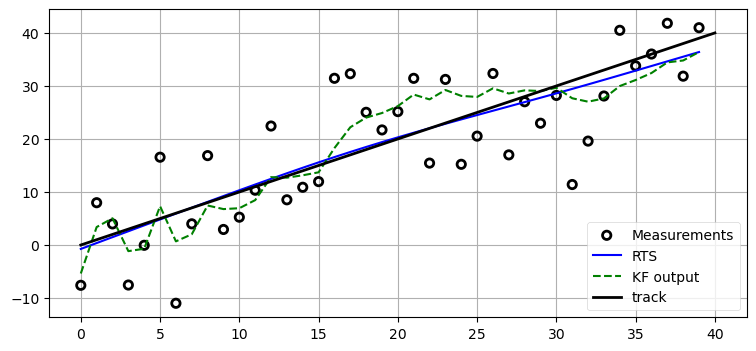

In [6]:
import numpy as np
from numpy import random
from numpy.random import randn
import matplotlib.pyplot as plt
from filterpy.kalman import KalmanFilter
from filterpy.common import Q_discrete_white_noise
import kf_book.book_plots as bp

def plot_rts(noise, Q=0.001, show_velocity=False):
    random.seed(123)
    fk = KalmanFilter(dim_x=2, dim_z=1)

    fk.x = np.array([0., 1.])      # state (x and dx)

    fk.F = np.array([[1., 1.],
                     [0., 1.]])    # state transition matrix

    fk.H = np.array([[1., 0.]])    # Measurement function
    fk.P*= 10.                     # covariance matrix
    fk.R = noise                   # state uncertainty
    fk.Q = Q_discrete_white_noise(dim=2, dt=1., var=Q)  # process uncertainty

    # create noisy data
    zs = np.asarray([t + randn()*noise for t in range (40)])

    # filter data with Kalman filter, than run smoother on it
    mu, cov, _, _ = fk.batch_filter(zs)
    M, P, C, _ = fk.rts_smoother(mu, cov)

    # plot data
    if show_velocity:
        index = 1
        print('gu')
    else:
        index = 0
    if not show_velocity:
        bp.plot_measurements(zs, lw=1)
    plt.plot(M[:, index], c='b', label='RTS')
    plt.plot(mu[:, index], c='g', ls='--', label='KF output')
    if not show_velocity:
        N = len(zs)
        plt.plot([0, N], [0, N], 'k', lw=2, label='track') 
    plt.legend(loc=4)
    plt.show()
    
plot_rts(7.)

I've injected a lot of noise into the signal to allow you to visually distinguish the RTS output from the ideal output. In the graph above we can see that the Kalman filter, drawn as the green dotted line, is reasonably smooth compared to the input, but it still wanders from from the ideal line when several measurements in a row are biased towards one side of the line. In contrast, the RTS output is both extremely smooth and very close to the ideal output.

我在信号里注入了大量噪声，好让你能一眼分清 RTS 输出与理想输出。上图中，画成绿色虚线的卡尔曼滤波器相比输入已经相当平滑，但当连续多个测量值都偏向直线某一侧时，它仍会偏离理想直线。相比之下，RTS 输出既极其平滑，又非常贴近理想输出。

With a perhaps more reasonable amount of noise we can see that the RTS output nearly lies on the ideal output. The Kalman filter output, while much better, still varies by a far greater amount.

把噪声降到比较合理的量级后，可以看到 RTS 输出几乎就落在理想输出上；卡尔曼滤波器的输出虽然也好得多，但起伏仍然大得多。


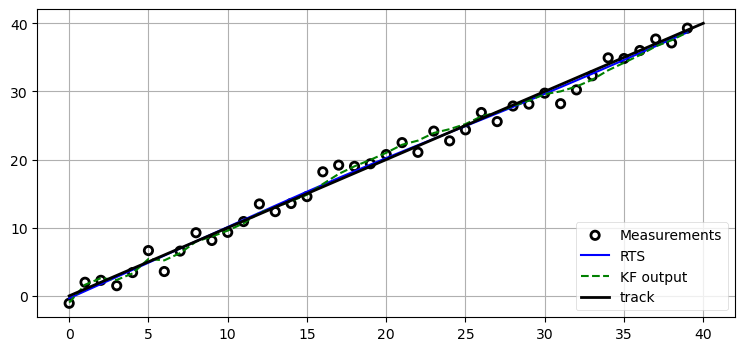

In [7]:
plot_rts(noise=1.)

However, we must understand that this smoothing is predicated on the system model. We have told the filter that what we are tracking follows a constant velocity model with very low process error. When the filter *looks ahead* it sees that the future behavior closely matches a constant velocity so it is able to reject most of the noise in the signal. Suppose instead our system has a lot of process noise. For example, if we are tracking a light aircraft in gusty winds its velocity will change often, and the filter will be less able to distinguish between noise and erratic movement due to the wind. We can see this in the next graph.

但必须明白，这种平滑是依赖系统模型的。我们已经告诉滤波器：所跟踪的对象遵循过程误差极小的恒速模型。当滤波器*向前看*时，会发现未来的行为与恒速模型十分吻合，因此能够剔除信号中的大部分噪声。反过来，假设系统本身过程噪声很大：例如在阵风中跟踪一架轻型飞机，它的速度会频繁变化，滤波器就难以分辨究竟是噪声，还是风造成的飘忽运动。这一点可以在下图中看到。


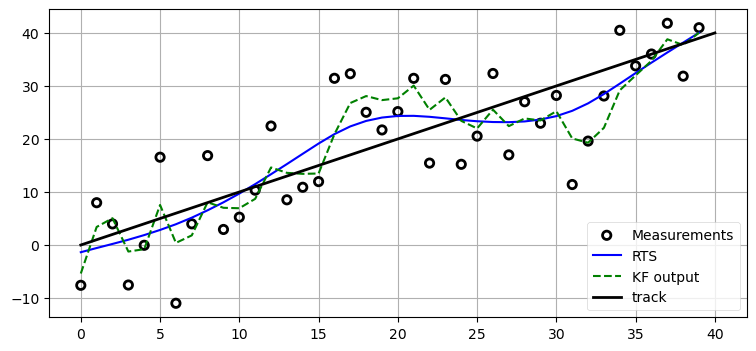

In [8]:
plot_rts(noise=7., Q=.1)

This underscores the fact that these filters are not *smoothing* the data in colloquial sense of the term. The filter is making an optimal estimate based on previous measurements, future measurements, and what you tell it about the behavior of the system and the noise in the system and measurements.

这凸显了一个事实：这些滤波器并不是在口语意义上对数据做*平滑*。滤波器会综合先前的测量、未来的测量，以及你告诉它的系统行为、系统噪声与测量噪声，做出最佳估计。

Let's wrap this up by looking at the velocity estimates of Kalman filter vs the RTS smoother.

最后，我们来看卡尔曼滤波器与 RTS 平滑器的速度估计，以此收尾。


gu


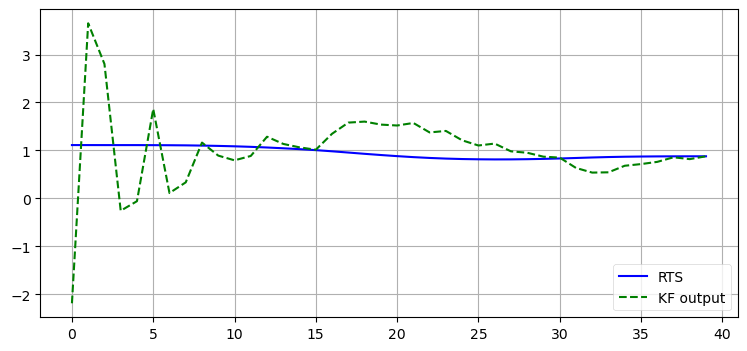

In [9]:
plot_rts(7.,show_velocity=True)

The improvement in the velocity, which is an hidden variable, is even more dramatic.

速度作为隐藏变量，其改进更加引人注目。


## Fixed-Lag Smoothing
## 固定滞后平滑

The RTS smoother presented above should always be your choice of algorithm if you can run in batch mode because it incorporates all available data into each estimate. Not all problems allow you to do that, but you may still be interested in receiving smoothed values for previous estimates. The number line below illustrates this concept.

只要你能以批处理方式运行，就应该优先选用上面介绍的 RTS 平滑器，因为它把全部可用数据都融入了每个估计。并非所有问题都允许这样做，但你仍可能希望得到先前各步估计的平滑值。下面的数轴说明了这个概念。


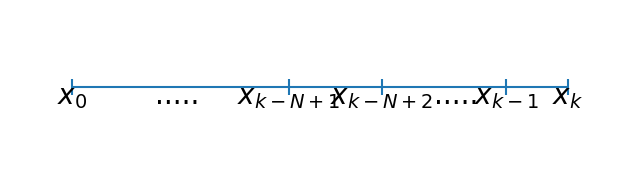

In [10]:
from kf_book.book_plots import figsize
from kf_book.smoothing_internal import *

with figsize(y=2):
    show_fixed_lag_numberline()

At step $k$ we can estimate $x_k$ using the normal Kalman filter equations. However, we can make a better estimate for $x_{k-1}$ by using the measurement received for $x_k$. Likewise, we can make a better estimate for $x_{k-2}$ by using the measurements received for $x_{k-1}$ and $x_{k}$. We can extend this computation back for an arbitrary $N$ steps.

在步骤 $k$，我们可以用常规的卡尔曼滤波器方程估计 $x_k$。但借助为 $x_k$ 收到的测量，我们可以对 $x_{k-1}$ 做出更好的估计；同理，借助为 $x_{k-1}$ 和 $x_{k}$ 收到的测量，又能改进对 $x_{k-2}$ 的估计。这个计算可以一路向前回溯任意 $N$ 步。

Derivation for this math is beyond the scope of this book; Dan Simon's *Optimal State Estimation* [2] has a very good exposition if you are interested. The essence of the idea is that instead of having a state vector $\mathbf{x}$ we make an augmented state containing

这部分数学的推导超出本书范围。如果你有兴趣，Dan Simon 的 *Optimal State Estimation* [2] 中有很好的阐述。其核心思想是：不用单纯的状态向量 $\mathbf{x}$，而是构造一个增广状态，包含下列各量

$$\mathbf{x} = \begin{bmatrix}\mathbf{x}_k \\ \mathbf{x}_{k-1} \\ \vdots\\\mathbf{x}_{k-N+1}\end{bmatrix}$$

This yields a very large covariance matrix that contains the covariance between states at different steps. FilterPy's class `FixedLagSmoother` takes care of all of this computation for you, including creation of the augmented matrices. All you need to do is compose it as if you are using the `KalmanFilter` class and then call `smooth()`, which implements the predict and update steps of the algorithm.

这会生成一个非常大的协方差矩阵，其中含有不同步骤状态之间的协方差。FilterPy 的 `FixedLagSmoother` 类会替你处理所有这些计算，包括构造增广矩阵。你要做的只是像使用 `KalmanFilter` 类那样把它组装起来，然后调用 `smooth()`，它实现了该算法的预测与更新步骤。

Each call of `smooth` computes the estimate for the current measurement, but it also goes back and adjusts the previous `N-1` points as well. The smoothed values are contained in the list `FixedLagSmoother.xSmooth`. If you use `FixedLagSmoother.x` you will get the most recent estimate, but it is not smoothed and is no different from a standard Kalman filter output.

每次调用 `smooth()` 都会算出当前测量的估计值，同时回头调整此前的 `N-1` 个点。平滑后的值存放在列表 `FixedLagSmoother.xSmooth` 中。如果改用 `FixedLagSmoother.x`，你得到的是最新估计值，但它未经平滑，与标准卡尔曼滤波器的输出没有区别。


standard deviation fixed-lag: 2.616
standard deviation kalman: 3.564


C:\Users\hhh\AppData\Local\Temp\ipykernel_27672\221685323.py:39: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  plt.plot(zs,'o', alpha=0.5, marker='o', label='zs')


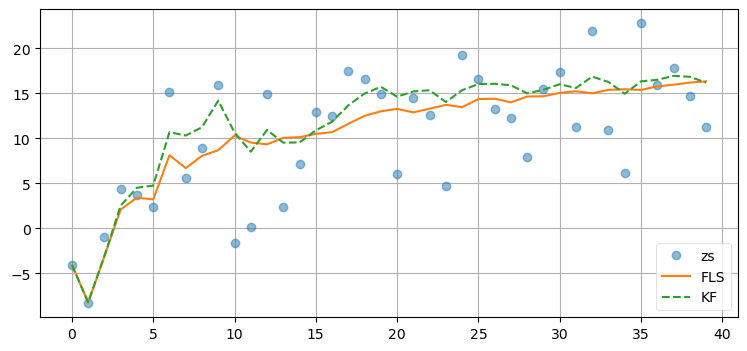

In [11]:
from filterpy.kalman import FixedLagSmoother, KalmanFilter
import numpy.random as random

fls = FixedLagSmoother(dim_x=2, dim_z=1, N=8)

fls.x = np.array([0., .5])
fls.F = np.array([[1.,1.],
                  [0.,1.]])

fls.H = np.array([[1.,0.]])
fls.P *= 200
fls.R *= 5.
fls.Q *= 0.001

kf = KalmanFilter(dim_x=2, dim_z=1)
kf.x = np.array([0., .5])
kf.F = np.array([[1.,1.],
                 [0.,1.]])
kf.H = np.array([[1.,0.]])
kf.P *= 200
kf.R *= 5.
kf.Q = Q_discrete_white_noise(dim=2, dt=1., var=0.001)

N = 4 # size of lag

nom =  np.array([t/2. for t in range (0, 40)])
zs = np.array([t + random.randn()*5.1 for t in nom])

for z in zs:
    fls.smooth(z)
    
kf_x, _, _, _ = kf.batch_filter(zs)
x_smooth = np.array(fls.xSmooth)[:, 0]


fls_res = abs(x_smooth - nom)
kf_res = abs(kf_x[:, 0] - nom)

plt.plot(zs,'o', alpha=0.5, marker='o', label='zs')
plt.plot(x_smooth, label='FLS')
plt.plot(kf_x[:, 0], label='KF', ls='--')
plt.legend(loc=4)

print(f'standard deviation fixed-lag: {np.mean(fls_res):.3f}')
print(f'standard deviation kalman: {np.mean(kf_res):.3f}')

Here I have set `N=8` which means that we will incorporate 8 future measurements into our estimates. This provides us with a very smooth estimate once the filter converges, at the cost of roughly 8x the amount of computation of the standard Kalman filter. Feel free to experiment with larger and smaller values of `N`. I chose 8 somewhat at random, not due to any theoretical concerns.

这里我设了 `N=8`，表示把 8 个未来的测量纳入估计。滤波器一旦收敛，就能给出非常平滑的估计，代价大约是标准卡尔曼滤波器计算量的 8 倍。不妨试试更大或更小的 `N`。我选 8 相当随意，并没有什么理论上的理由。


## References
## 参考文献

- [1] H. Rauch, F. Tung, and C. Striebel. "Maximum likelihood estimates of linear dynamic systems," *AIAA Journal*, **3**(8), pp. 1445-1450 (August 1965). http://arc.aiaa.org/doi/abs/10.2514/3.3166

- [2] Dan Simon. "Optimal State Estimation," John Wiley & Sons, 2006.
